# Programa de Fidelidade - Clusterizacao de Clientes (INSIDERS)

# 0.0. Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('..')

import re
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

from sklearn import decomposition as dd
from sklearn import ensemble as en
from sklearn import manifold as mn
from sklearn import preprocessing as pp
from sklearn import metrics as skmetrics
from sklearn.neighbors import NearestNeighbors
import umap.umap_ as umap

from src.data.make_dataset import (
    load_raw, rename_columns, fill_missing_customer_id, fix_dtypes, filter_records,
    split_returns_purchases,
)
from src.features.build_features import (
    create_reference, add_gross_revenue, add_recency, add_qtde_products,
    add_frequency, add_qtde_returns, RFM_COLUMNS,
)
from src.models.clustering import (
    scale_features, tune_clustering, run_dbscan, train_final_model, save_artifacts,
)
from src.visualization.plots import plot_silhouette_scores, plot_cluster_embedding

C:\Users\ricar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1. Nota sobre o input do clustering

Nesta versao, o K-Means/GMM/Hierarchical Clustering roda **diretamente sobre as features RFM escaladas** (`gross_revenue`, `recency_days`, `qtde_products`, `frequency`, `qtde_returns`), nao sobre um embedding UMAP de arvore como na versao anterior deste projeto.

Motivo: usar o embedding como input reduz a interpretabilidade do cluster (a distancia entre pontos deixa de ter significado direto em termos de gasto/recencia/frequencia) e usa o UMAP fora do que ele foi desenhado para fazer (preservar vizinhanca local para visualizacao, nao servir de espaco metrico de um algoritmo de distancia como K-Means). PCA/UMAP/t-SNE continuam explorados na secao 4.3 e a decisao formal de nao usa-los como input fica registrada na secao 6.0.

# 1.0. Descricao dos dados

In [2]:
df_raw = load_raw()
print('Number of rows: {}'.format(df_raw.shape[0]))
print('Number of cols: {}'.format(df_raw.shape[1]))
df_raw.head()

Number of rows: 541909
Number of cols: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


## 1.1. Rename columns

In [3]:
df1 = rename_columns(df_raw)
df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


## 1.2. Data types

In [4]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

## 1.3. Check NA

In [5]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## 1.4. Replace NA

Invoices sem `customer_id` recebem um id sintetico (19000+), ancorado no `invoice_no` -- assim linhas da mesma nota fiscal sem cliente identificado caem no mesmo id.

In [6]:
df1 = fill_missing_customer_id(df1)
df1.isna().sum()

invoice_no         0
stock_code         0
description     1454
quantity           0
invoice_date       0
unit_price         0
country            0
customer_id        0
dtype: int64

## 1.5. Change dtypes

In [7]:
df1 = fix_dtypes(df1)
df1.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
country                 object
customer_id              int64
dtype: object

## 1.6. Descriptive Statistics

### 1.6.1. Numerical Attributes

In [8]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
num_attributes.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
unit_price,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
customer_id,541909.0,16688.840453,2911.411352,12346.00,14367.00,16249.00,18283.00,22709.0


### 1.6.2. Categorical Attributes
#### Invoice No

Alguns `invoice_no` tem letras (nao sao so numericos) -- checando se isso concentra devolucoes (quantidade negativa).

In [9]:
df_letter_invoices = df1.loc[df1['invoice_no'].apply(lambda x: bool(re.search('[^0-9]+', x))), :]
print('Total number of invoices: {}'.format(len(df_letter_invoices)))
print('Total number of negative quantity: {}'.format(len(df_letter_invoices[df_letter_invoices['quantity'] < 0])))

Total number of invoices: 9291
Total number of negative quantity: 9288


#### Stock Code

Codigos so com letras (sem numero) tendem a ser taxas/postagem/amostra, nao produto de verdade -- sao a base da lista `EXCLUDED_STOCK_CODES` filtrada na secao 2.0.

In [10]:
df1.loc[df1['stock_code'].apply(lambda x: bool(re.search('^[a-zA-Z]+$', x))), 'stock_code'].unique()

array(['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY',
       'DCGSSGIRL', 'PADS', 'B', 'CRUK'], dtype=object)

#### Description

Texto livre, sem uso no RFM -- sera removida na filtragem (secao 2.0).

#### Country

In [11]:
df1['country'].value_counts(normalize=True).head()

country
United Kingdom    0.914320
Germany           0.017521
France            0.015790
EIRE              0.015124
Spain             0.004674
Name: proportion, dtype: float64

In [12]:
df1[['customer_id', 'country']].drop_duplicates().groupby('country').count().reset_index().sort_values('customer_id', ascending=False).head()

,country,customer_id
36,United Kingdom,7587
14,Germany,95
13,France,90
10,EIRE,44
31,Spain,31


# 2.0. Filtragem de Variaveis

Regras aplicadas por `filter_records` (ver `src/data/make_dataset.py`):
- `unit_price >= 0.04` (remove itens gratuitos/erro de cadastro)
- remove `stock_code` que sao taxa/postagem/amostra, nao produto
- remove a coluna `description` (nao usada no RFM)
- remove paises `European Community` / `Unspecified` (nao sao pais real)
- remove o `customer_id` 16446 (outlier extremo identificado na EDA)

In [13]:
print('Rows before filtering: {}'.format(df1.shape[0]))
df2 = filter_records(df1)
print('Rows after filtering: {}'.format(df2.shape[0]))
df2.head()

Rows before filtering: 541909


Rows after filtering: 536139


,invoice_no,stock_code,quantity,invoice_date,unit_price,country,customer_id
0,536365,85123A,6,2016-11-29,2.55,United Kingdom,17850
1,536365,71053,6,2016-11-29,3.39,United Kingdom,17850
2,536365,84406B,8,2016-11-29,2.75,United Kingdom,17850
3,536365,84029G,6,2016-11-29,3.39,United Kingdom,17850
4,536365,84029E,6,2016-11-29,3.39,United Kingdom,17850


# 3.0. Feature Engineering (RFM)

In [14]:
returns, purchases = split_returns_purchases(df2)
print('Purchases: {} | Returns: {}'.format(len(purchases), len(returns)))

Purchases: 527411 | Returns: 8728


## 3.1. Reference table (um cliente por linha)

In [15]:
df_ref = create_reference(df2)
df_ref.shape

(5786, 1)

## 3.2. Gross Revenue

In [16]:
df_ref = add_gross_revenue(df_ref, purchases)
df_ref.isna().sum()

customer_id       0
gross_revenue    91
dtype: int64

## 3.3. Recency - dias desde a ultima compra

In [17]:
df_ref = add_recency(df_ref, df2, purchases)
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

## 3.4. Quantidade de produtos comprados

In [18]:
df_ref = add_qtde_products(df_ref, purchases)
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
dtype: int64

## 3.5. Frequencia de compra

In [19]:
df_ref = add_frequency(df_ref, purchases)
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
frequency        91
dtype: int64

## 3.6. Numero de devolucoes

Clientes sem devolucao registrada viram `qtde_returns = 0` (nao ficam como NA).

In [20]:
df_ref = add_qtde_returns(df_ref, returns)
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
frequency        91
qtde_returns      0
dtype: int64

# 4.0. EDA (Exploratory Data Analysis)

In [21]:
df4 = df_ref.dropna().reset_index(drop=True)
print('Number of customers: {}'.format(df4['customer_id'].nunique()))
df4[RFM_COLUMNS].describe().T

Number of customers: 5695


,count,mean,std,min,25%,50%,75%,max
gross_revenue,5695.0,1774.303486,7582.209661,0.42000,236.135000,613.2,1570.74,279138.02
recency_days,5695.0,116.927656,111.646363,0.00000,23.000000,71.0,200.00,373.00
qtde_products,5695.0,92.609482,210.578598,1.00000,14.000000,41.0,106.00,7838.00
frequency,5695.0,0.547297,0.550257,0.00545,0.024926,1.0,1.00,17.00
qtde_returns,5695.0,31.268306,1004.321707,0.00000,0.000000,0.0,1.00,74215.00


## 4.1. Univariate Analysis

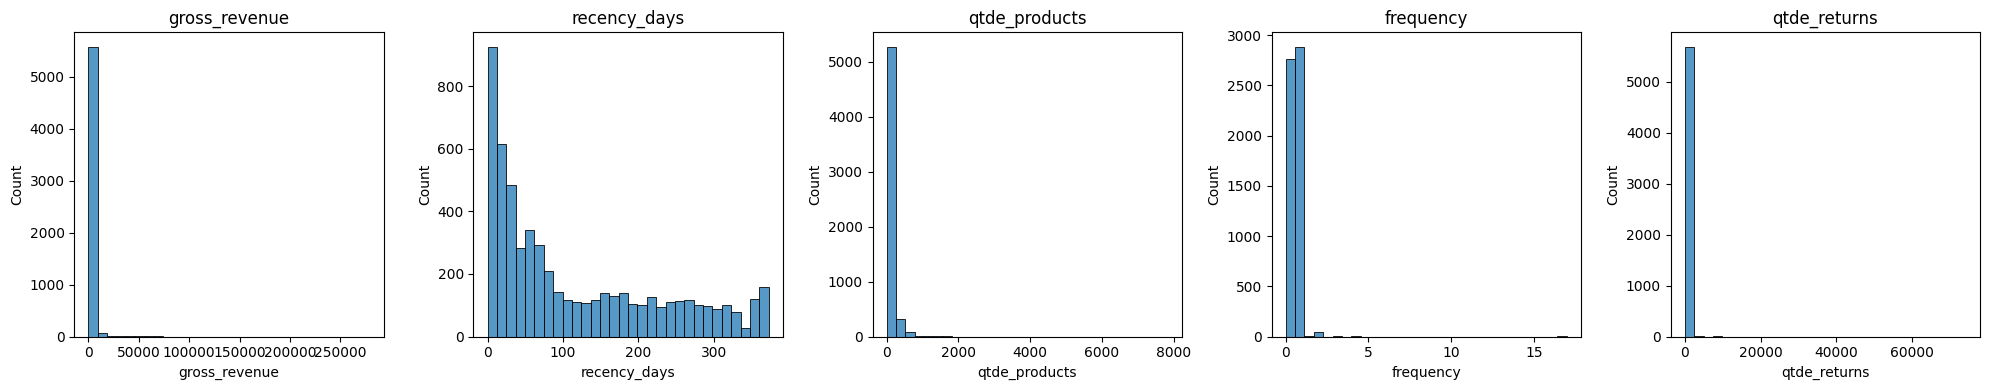

In [22]:
fig, axes = plt.subplots(1, len(RFM_COLUMNS), figsize=(20, 4))
for ax, col in zip(axes, RFM_COLUMNS):
    sns.histplot(df4[col], ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4.2. Bivariate Analysis

Amostra de 1000 clientes (o pairplot completo com >5000 pontos e KDE na diagonal leva minutos) e histograma em vez de KDE na diagonal, so para inspecionar visualmente a relacao entre pares de features.

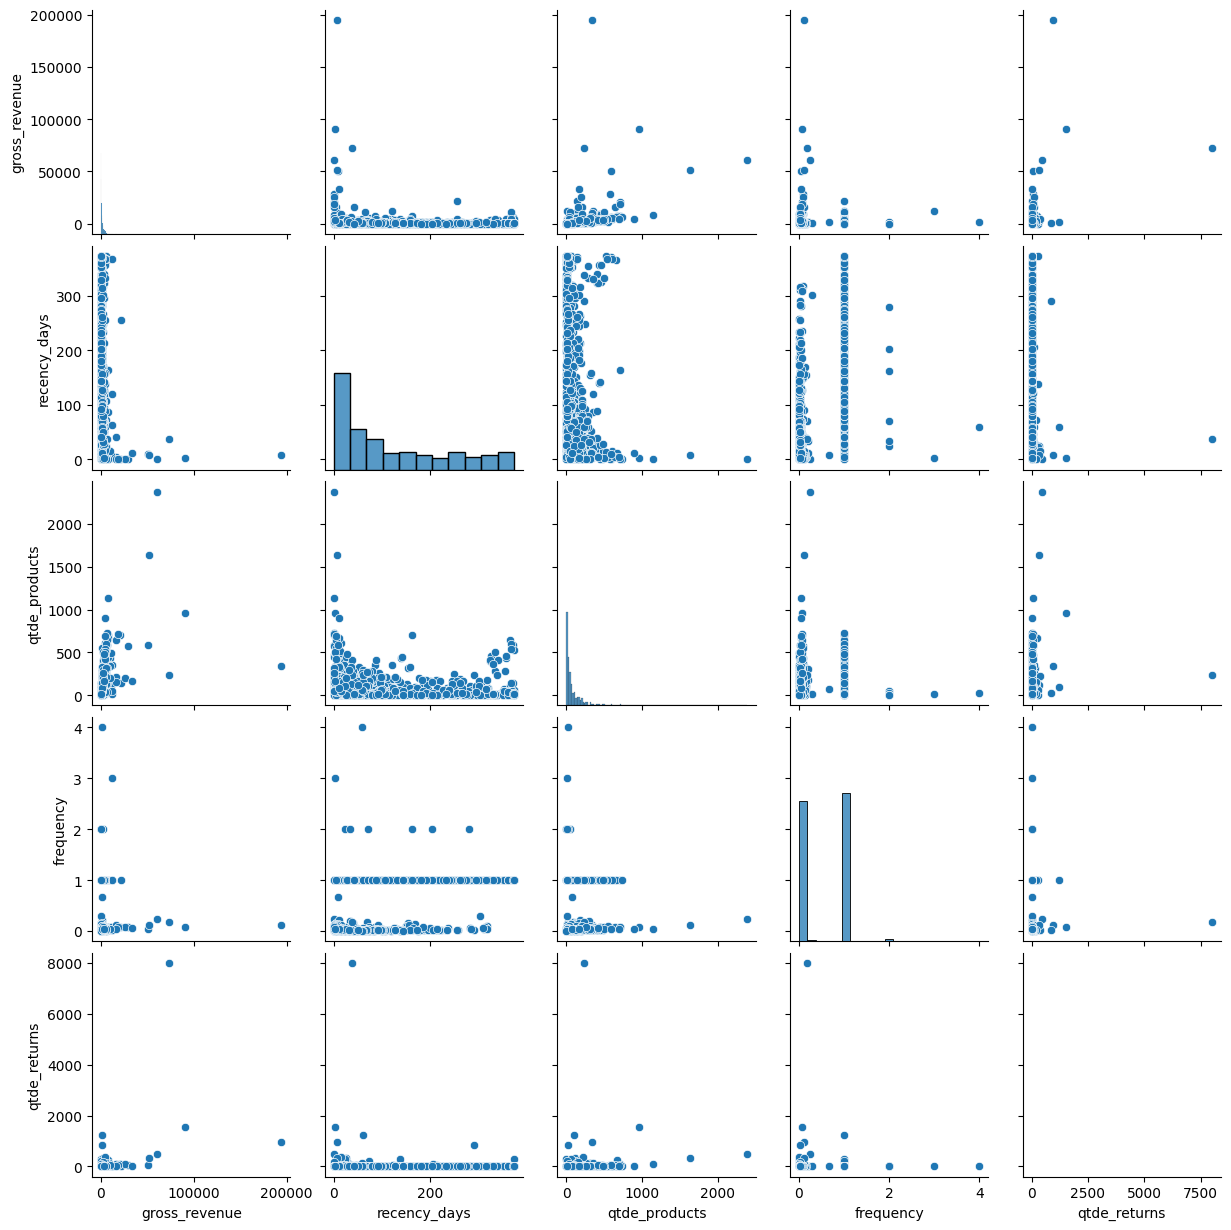

In [23]:
df42 = df4[RFM_COLUMNS].sample(n=1000, random_state=42)
sns.pairplot(df42, diag_kind='hist')
plt.show()

## 4.3. Estudo do Espaco

Exploracao apenas -- nenhuma das representacoes abaixo (PCA/UMAP/t-SNE/embedding de arvore) e usada como input do clustering. A decisao formal do que sera usado fica na secao 6.0 (Feature Selection).

In [24]:
mm_explore = pp.MinMaxScaler()
X_explore = pd.DataFrame(mm_explore.fit_transform(df4[RFM_COLUMNS]), columns=RFM_COLUMNS)
X_explore.shape

(5695, 5)

### 4.3.1. PCA

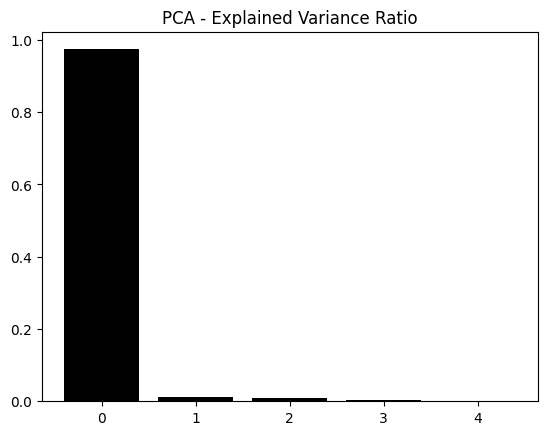

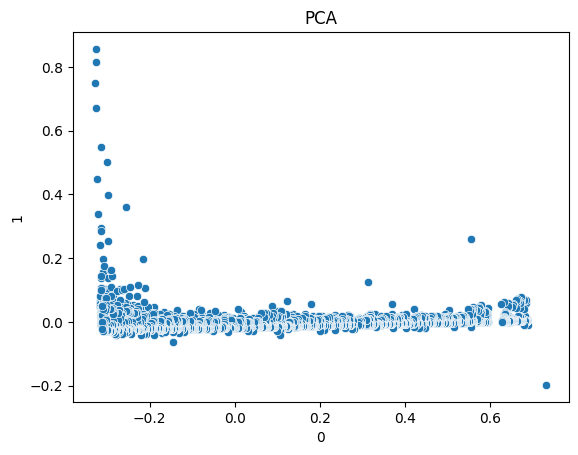

In [25]:
pca = dd.PCA(n_components=X_explore.shape[1])
principal_components = pca.fit_transform(X_explore)

plt.bar(range(pca.n_components_), pca.explained_variance_ratio_, color='black')
plt.title('PCA - Explained Variance Ratio')
plt.show()

df_pca = pd.DataFrame(principal_components)
sns.scatterplot(x=0, y=1, data=df_pca)
plt.title('PCA')
plt.show()

### 4.3.2. UMAP

C:\Users\ricar\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


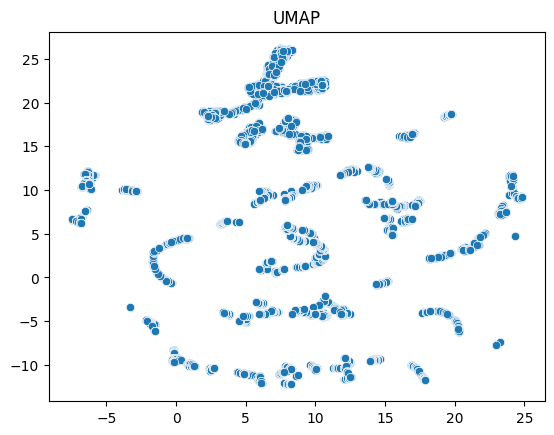

In [26]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_explore)
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1])
plt.title('UMAP')
plt.show()

### 4.3.3. t-SNE

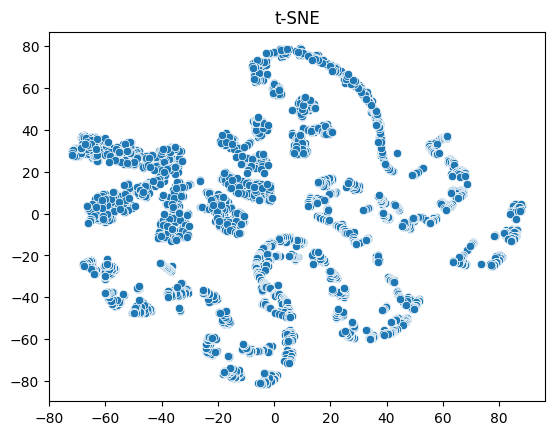

In [27]:
reducer = mn.TSNE(n_components=2, n_jobs=-1, random_state=42)
embedding = reducer.fit_transform(X_explore)
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1])
plt.title('t-SNE')
plt.show()

### 4.3.4. Tree-Based Embedding

C:\Users\ricar\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\ricar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


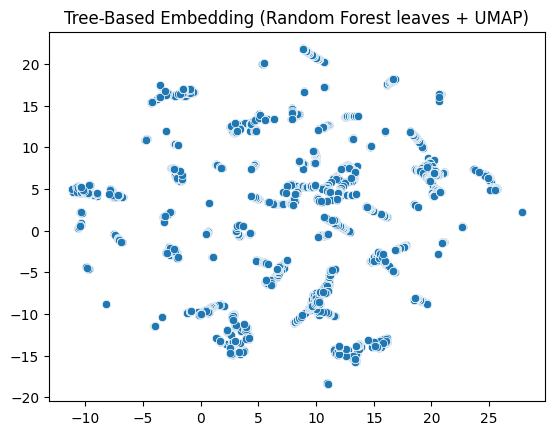

In [28]:
X_tree_input = X_explore.drop(columns=['gross_revenue'])
y_tree = X_explore['gross_revenue']

rf_model = en.RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_tree_input, y_tree)

df_leaf = pd.DataFrame(rf_model.apply(X_tree_input))
reducer = umap.UMAP(random_state=42)
tree_embedding = reducer.fit_transform(df_leaf)
sns.scatterplot(x=tree_embedding[:, 0], y=tree_embedding[:, 1])
plt.title('Tree-Based Embedding (Random Forest leaves + UMAP)')
plt.show()

# 5.0. Data Preparation

Na versao anterior deste notebook, esta secao era so um `.copy()` sem nenhuma transformacao -- o `MinMaxScaler` de verdade acontecia cedo demais, dentro da 4.3. Aqui e onde a preparacao final para o clustering acontece de fato.

`gross_revenue`, `qtde_products`, `frequency` e `qtde_returns` sao fortemente assimetricos (poucos clientes de altissimo volume puxam o desvio padrao para bem acima da media). `scale_features` aplica `log1p` nessas 4 colunas antes do `MinMaxScaler` (mantendo `recency_days` como esta, pois nao e uma distribuicao de cauda longa) -- o motivo quantitativo esta demonstrado na secao 6.0.

In [29]:
X, scaler = scale_features(df4)
X.head()

,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,0.676198,0.997319,0.604800,1.000000,0.331133
1,0.634245,0.150134,0.538373,0.007790,0.319537
2,0.694092,0.005362,0.575061,0.011819,0.350595
3,0.533688,0.254692,0.323210,0.004273,0.000000
4,0.527193,0.892761,0.083777,0.022594,0.279587


# 6.0. Feature Selection

Na versao anterior, esta secao tambem era so um `.copy()`. Aqui registramos as duas decisoes que definem o `X` usado no clustering.

## 6.1. RFM direto em vez de embedding

Rejeitamos as representacoes da secao 4.3 (PCA/UMAP/t-SNE/tree-embedding) como input do clustering: elas otimizam para visualizacao (preservar vizinhanca local), nao para servir de espaco metrico de um algoritmo baseado em distancia, e tornam o cluster resultante dificil de explicar em termos de negocio. Ficam mantidas so como exploracao visual.

## 6.2. log1p antes do MinMaxScaler

Evidencia quantitativa: comparando o GMM sobre o RFM escalado **sem** log-transform vs. **com** log-transform (secao 5.0), no mesmo k.

In [30]:
from sklearn import mixture as mx

mm_raw = pp.MinMaxScaler()
X_raw = pd.DataFrame(mm_raw.fit_transform(df4[RFM_COLUMNS]), columns=RFM_COLUMNS)

for k in [3, 5, 8]:
    sil_raw = skmetrics.silhouette_score(X_raw, mx.GaussianMixture(n_components=k, random_state=42).fit_predict(X_raw))
    sil_log = skmetrics.silhouette_score(X, mx.GaussianMixture(n_components=k, random_state=42).fit_predict(X))
    print('k={} | GMM sem log: {:.4f} | GMM com log1p: {:.4f}'.format(k, sil_raw, sil_log))

k=3 | GMM sem log: -0.2243 | GMM com log1p: 0.0628


k=5 | GMM sem log: -0.1170 | GMM com log1p: 0.1891


k=8 | GMM sem log: -0.2177 | GMM com log1p: 0.1354


Sem o log-transform, o GMM fica com Silhouette Score negativo (clusters sobrepostos) em todo k testado -- a suposicao Gaussiana de cada cluster quebra com a cauda longa dos dados. Com `log1p`, o Silhouette fica positivo. **Decisao: usar `X` (RFM com log1p + MinMaxScaler) da secao 5.0 no clustering.**

# 7.0. Hyperparameter Fine-Tuning

In [31]:
k_range = np.arange(2, 15, 1)
k_range

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 7.1. K-Means + GMM + Hierarchical Clustering

In [32]:
df_results = tune_clustering(X, k_range)
df_results

,2,3,4,5,6,7,8,9,10,11,12,13,14
KMeans,0.441995,0.329944,0.308276,0.286630,0.294754,0.284152,0.272657,0.275630,0.273641,0.286957,0.280383,0.285291,0.289346
GMM,0.253423,0.062775,0.106529,0.189101,-0.014886,0.023830,0.135410,0.080245,-0.019800,0.085577,0.004138,0.031137,0.057866
HC,0.407063,0.319477,0.291001,0.247174,0.244885,0.245526,0.222111,0.217833,0.216657,0.227684,0.222516,0.221056,0.219723


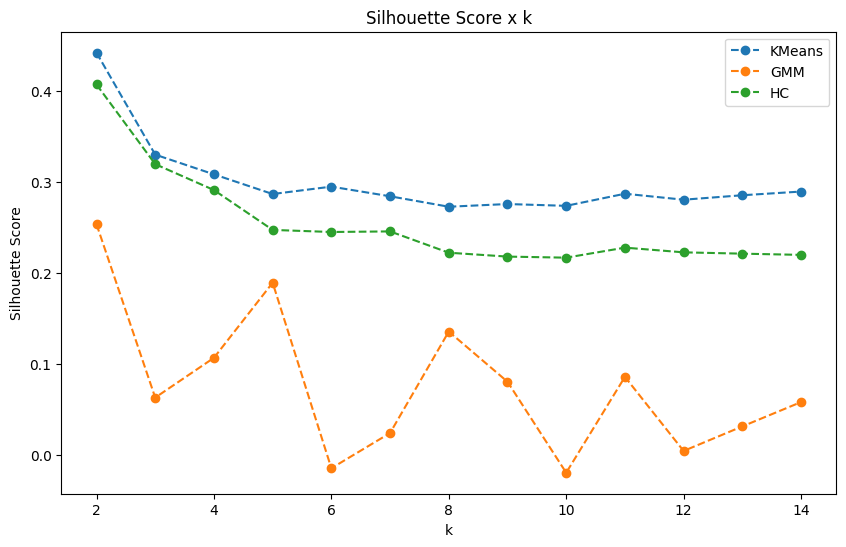

In [33]:
fig = plot_silhouette_scores(df_results)
plt.show()

## 7.2. DBSCAN

Na versao anterior, os resultados do DBSCAN eram uma lista hardcoded (`[0.622034, 0, 0, 0, 0, 0]`), aparentemente colada de uma execucao feita fora do notebook, com `eps=2.00` -- valor calibrado para o espaco do embedding 2D antigo. Como o input do clustering mudou para RFM em 5 dimensoes (secao 5.0/6.0), esse eps precisa ser recalibrado: `eps=2.00` neste novo espaco colapsa todos os pontos em 1 cluster so. O grafico de k-distancia abaixo escolhe um `eps` adequado ao novo espaco, e o resultado e recalculado ao vivo, reproduzivel.

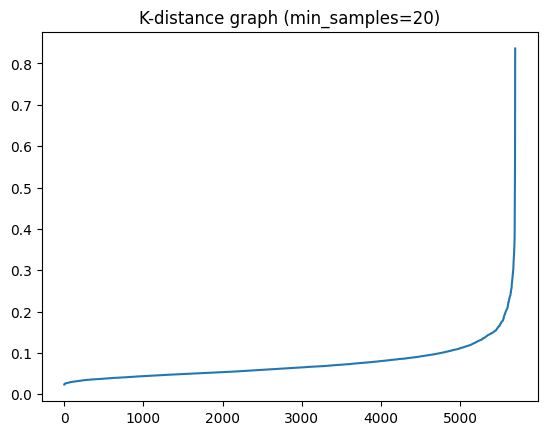

In [34]:
min_samples = 20
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = neighbors.kneighbors(X)
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title('K-distance graph (min_samples={})'.format(min_samples))
plt.show()

In [35]:
eps = 0.10  # cotovelo do grafico de k-distancia acima (~percentil 90)
labels_dbscan, sil_dbscan, n_clusters_dbscan = run_dbscan(X, eps=eps, min_samples=min_samples)
print('eps={} | Silhouette: {} | Number of clusters: {}'.format(eps, sil_dbscan, n_clusters_dbscan))

eps=0.1 | Silhouette: 0.22995384675223168 | Number of clusters: 2


## 7.3. Resultados

DBSCAN fica fora da tabela comparativa por k (nao e parametrizado por numero de clusters da mesma forma) -- mesma escolha do notebook original.

In [36]:
df_results.style.highlight_max(color='lightgreen', axis=1)

,2,3,4,5,6,7,8,9,10,11,12,13,14
KMeans,0.441995,0.329944,0.308276,0.286630,0.294754,0.284152,0.272657,0.275630,0.273641,0.286957,0.280383,0.285291,0.289346
GMM,0.253423,0.062775,0.106529,0.189101,-0.014886,0.023830,0.135410,0.080245,-0.019800,0.085577,0.004138,0.031137,0.057866
HC,0.407063,0.319477,0.291001,0.247174,0.244885,0.245526,0.222111,0.217833,0.216657,0.227684,0.222516,0.221056,0.219723


## 7.4. Por que k=5 em vez do maximo estatistico

O maior Silhouette Score da tabela acima cai em k=2 -- uma divisao grosseira da base ao meio (bons vs. resto), o que nao atende ao objetivo de negocio de achar um **segmento pequeno de elite** para o programa INSIDERS. Comparando k=4 e k=5 (ambos com Silhouette positivo e bem abaixo de k=2, mas produzindo segmentos utilizaveis), k=5 isola um cluster de ~13% dos clientes com receita media alta **e** recencia de compra muito baixa (clientes ativos agora, nao so historicamente valiosos) -- o perfil mais acionavel para o programa de fidelidade. k=5 tambem mantem a escolha original do projeto.

# 8.0. Model Training

## 8.1. Final model

In [37]:
k = 5
gmm_model = train_final_model(X, k=k)
labels = gmm_model.predict(X)

## 8.2. Cluster Validation

In [38]:
print('SS value: {}'.format(skmetrics.silhouette_score(X, labels, metric='euclidean')))

SS value: 0.07224098633721317


# 9.0. Cluster Analysis

## 9.1. Visualization Inspection

C:\Users\ricar\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


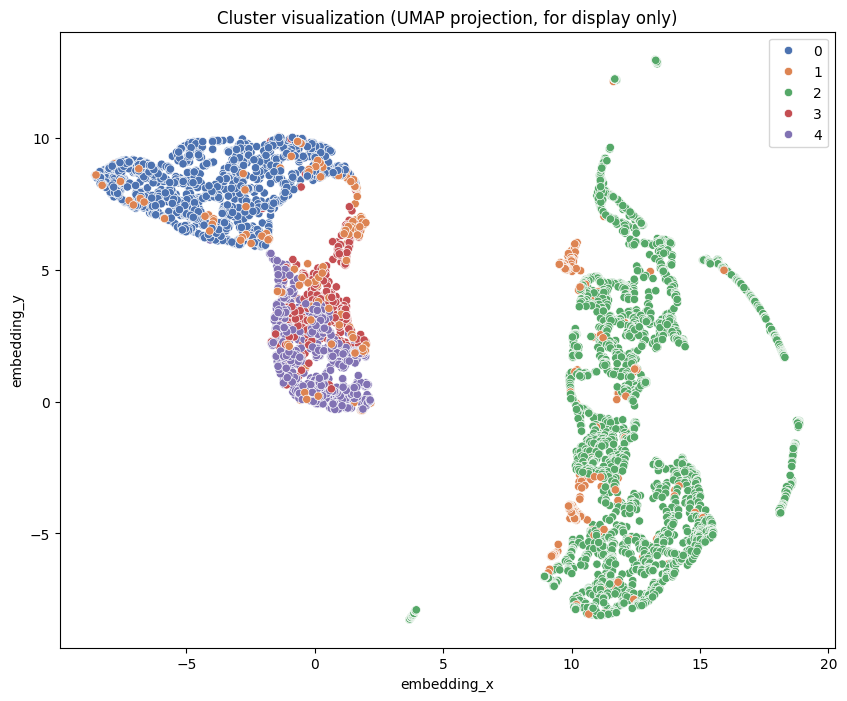

In [39]:
fig = plot_cluster_embedding(X, labels)
plt.show()

## 9.2. Cluster Profile

In [40]:
df9 = df4.copy()
df9['cluster'] = labels

df_profile = df9[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_profile.columns = ['cluster', 'customer_count']
df_profile['perc_customer'] = 100 * (df_profile['customer_count'] / df_profile['customer_count'].sum())

for col in RFM_COLUMNS:
    avg = df9[[col, 'cluster']].groupby('cluster').mean().reset_index()
    avg.columns = ['cluster', col]
    df_profile = pd.merge(df_profile, avg, how='inner', on='cluster')

df_profile = df_profile.sort_values('gross_revenue', ascending=False).reset_index(drop=True)
df_profile

,cluster,customer_count,perc_customer,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,4,753,13.222125,5194.964382,13.616202,205.276228,0.037041,74.698539
1,1,416,7.304653,4030.868365,149.709135,124.867788,0.874328,272.079327
2,3,430,7.550483,1600.269791,82.425581,89.546512,0.022192,20.093023
3,0,1423,24.986831,1312.827105,63.166550,85.722417,0.030007,0.000000
4,2,2673,46.935909,733.161223,175.099888,60.009353,1.000000,0.000000


## 9.3. Identificacao do cluster INSIDERS

Por definicao do projeto (README, secao 3.0 Produto Final): o cluster com maior faturamento medio e o grupo INSIDERS.

In [41]:
insider_cluster = int(df_profile.iloc[0]['cluster'])
print('Cluster INSIDERS: {}'.format(insider_cluster))

Cluster INSIDERS: 4


# 10.0. Analise Exploratoria de Hipoteses

## Hipoteses de negocio

1. Os clientes do cluster insiders possuem um volume (produtos) de compras acima de 10% do total de compras
2. Os clientes do cluster insiders possuem um volume (faturamento) de compras acima de 10% do total de compras
3. Os clientes do cluster insiders tem um numero de devolucao abaixo da media da base total de clientes
4. A mediana do faturamento pelos clientes do cluster insider e 10% maior do que a mediana do faturamento geral
5. O percentil do GMV pelos clientes insiders

No notebook original, H4 e H5 ficavam listadas mas nunca eram calculadas -- aqui as duas sao implementadas.

### H1. Volume de produtos

In [42]:
products_insiders = df9.loc[df9['cluster'] == insider_cluster, 'qtde_products'].sum()
products_total = df9['qtde_products'].sum()
pct_products = 100 * products_insiders / products_total
print('% Produtos Insiders: {:.2f}%'.format(pct_products))
print('Verdadeiro' if pct_products > 10 else 'Falso')

% Produtos Insiders: 29.31%
Verdadeiro


### H2. Volume de faturamento (GMV)

In [43]:
gmv_insiders = df9.loc[df9['cluster'] == insider_cluster, 'gross_revenue'].sum()
gmv_total = df9['gross_revenue'].sum()
pct_gmv = 100 * gmv_insiders / gmv_total
print('% GMV Insiders: {:.2f}%'.format(pct_gmv))
print('Verdadeiro' if pct_gmv > 10 else 'Falso')

% GMV Insiders: 38.71%
Verdadeiro


### H3. Devolucoes

In [44]:
avg_return_insiders = df9.loc[df9['cluster'] == insider_cluster, 'qtde_returns'].mean()
avg_return_all = df9['qtde_returns'].mean()
print('Avg Return Insiders: {:.2f} vs Avg Return All: {:.2f}'.format(avg_return_insiders, avg_return_all))
print('Verdadeiro' if avg_return_insiders < avg_return_all else 'Falso')

Avg Return Insiders: 74.70 vs Avg Return All: 31.27
Falso


### H4. Mediana do faturamento

In [45]:
median_insiders = df9.loc[df9['cluster'] == insider_cluster, 'gross_revenue'].median()
median_all = df9['gross_revenue'].median()
pct_diff = 100 * (median_insiders / median_all - 1)
print('Mediana Insiders: {:.2f} | Mediana Geral: {:.2f} | Diferenca: {:.2f}%'.format(median_insiders, median_all, pct_diff))
print('Verdadeiro' if pct_diff > 10 else 'Falso')

Mediana Insiders: 2616.38 | Mediana Geral: 613.20 | Diferenca: 326.68%
Verdadeiro


### H5. Percentil do GMV dos insiders

In [46]:
percentile = stats.percentileofscore(df9['gross_revenue'], median_insiders)
print('A mediana de faturamento dos Insiders esta no percentil {:.1f} da base geral de clientes'.format(percentile))

A mediana de faturamento dos Insiders esta no percentil 86.0 da base geral de clientes


# 11.0. Deploy To Production

Na versao anterior, esta secao era so um titulo, sem conteudo. Aqui persistimos o modelo para reuso futuro (ex.: uma API que classifica um cliente novo) e exportamos o produto final do projeto: a tabela de clusters ordenada por faturamento (README, secao 3.0).

## 11.1. Persistencia do scaler e do modelo

In [47]:
save_artifacts(scaler, gmm_model)
print('scaler e modelo salvos em ../models/')

scaler e modelo salvos em ../models/


## 11.2. Exportacao da tabela final

In [48]:
df9.to_csv('../data/processed/customer_clusters.csv', index=False)
df_profile.to_csv('../data/processed/cluster_profile.csv', index=False)
print('tabelas exportadas em ../data/processed/')

tabelas exportadas em ../data/processed/
